In [16]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set Seaborn style
sns.set_theme(style="whitegrid")  # Using seaborn's whitegrid style
sns.set_palette("husl")  # Setting color palette


In [17]:
# Load the dataset
df = pd.read_csv('spotify_emeritus.csv')

# Remove unnecessary columns and handle missing values
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)
df = df.dropna()


In [18]:
# Prepare features for base model
from sklearn.preprocessing import LabelEncoder

# Handle categorical variables with label encoding
# Genre encoding
le_genre = LabelEncoder()
df['genre_label_encoded'] = le_genre.fit_transform(df['track_genre'])

# Artist encoding
le_artist = LabelEncoder()
df['artist_label_encoded'] = le_artist.fit_transform(df['artists'])

# Album encoding
le_album = LabelEncoder()
df['album_label_encoded'] = le_album.fit_transform(df['album_name'])

# Define base features for modeling
base_features = [
    # Audio features
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
    
    # Musical features
    'key', 'mode', 'time_signature',
    
    # Metadata features
    'explicit',
    'genre_label_encoded',
    'artist_label_encoded',
    'album_label_encoded',
    
    # Duration (in minutes)
    'duration_ms'
]

# Create feature matrix X and target variable y
X = df[base_features]
y = df['popularity']

# Convert boolean to int
X['explicit'] = X['explicit'].astype(int)

# Convert duration to minutes for better interpretability
X['duration_ms'] = X['duration_ms'] / 60000

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


/var/folders/n8/sjn78y6j62bbb0w0_cywfkk40000gn/T/ipykernel_52260/587609195.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['explicit'] = X['explicit'].astype(int)
/var/folders/n8/sjn78y6j62bbb0w0_cywfkk40000gn/T/ipykernel_52260/587609195.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['duration_ms'] = X['duration_ms'] / 60000


In [19]:
# Initialize models with tuned parameters
models = {
    'Decision Tree': DecisionTreeRegressor(
        max_depth=10,
        min_samples_split=5,
        random_state=42
    ),
    'Random Forest': RandomForestRegressor(
        n_estimators=50,
        max_depth=15,
        min_samples_split=5,
        random_state=42
    ),
    'XGBoost': xgb.XGBRegressor(
        n_estimators=50,
        max_depth=7,
        learning_rate=0.1,
        random_state=42
    )
}


In [20]:
# Set up K-Fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Initialize lists to store fold scores
    fold_rmse = []
    
    # Perform manual k-fold cross-validation
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        # Split data for this fold
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # Train model
        model.fit(X_fold_train, y_fold_train)
        
        # Make predictions
        y_fold_pred = model.predict(X_fold_val)
        
        # Calculate RMSE for this fold
        fold_rmse.append(np.sqrt(mean_squared_error(y_fold_val, y_fold_pred)))
        
    # Calculate cross-validation statistics
    cv_rmse_mean = np.mean(fold_rmse)
    cv_rmse_std = np.std(fold_rmse)
    
    # Train model on full training set
    model.fit(X_train, y_train)
    
    # Make predictions on test set
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'cv_rmse_mean': cv_rmse_mean,
        'cv_rmse_std': cv_rmse_std,
        'test_rmse': rmse,
        'test_mae': mae,
        'test_r2': r2
    }
    
    print(f"{name} Results:")
    print(f"Cross-validation RMSE: {cv_rmse_mean:.2f} (+/- {cv_rmse_std*2:.2f})")
    print(f"Test RMSE: {rmse:.2f}")
    print(f"Test MAE: {mae:.2f}")
    print(f"Test R²: {r2:.3f}")



Training Decision Tree...
Decision Tree Results:
Cross-validation RMSE: 20.21 (+/- 0.11)
Test RMSE: 20.20
Test MAE: 15.88
Test R²: 0.178

Training Random Forest...
Random Forest Results:
Cross-validation RMSE: 17.14 (+/- 0.22)
Test RMSE: 16.93
Test MAE: 13.12
Test R²: 0.422

Training XGBoost...
XGBoost Results:
Cross-validation RMSE: 17.93 (+/- 0.09)
Test RMSE: 17.85
Test MAE: 13.90
Test R²: 0.358


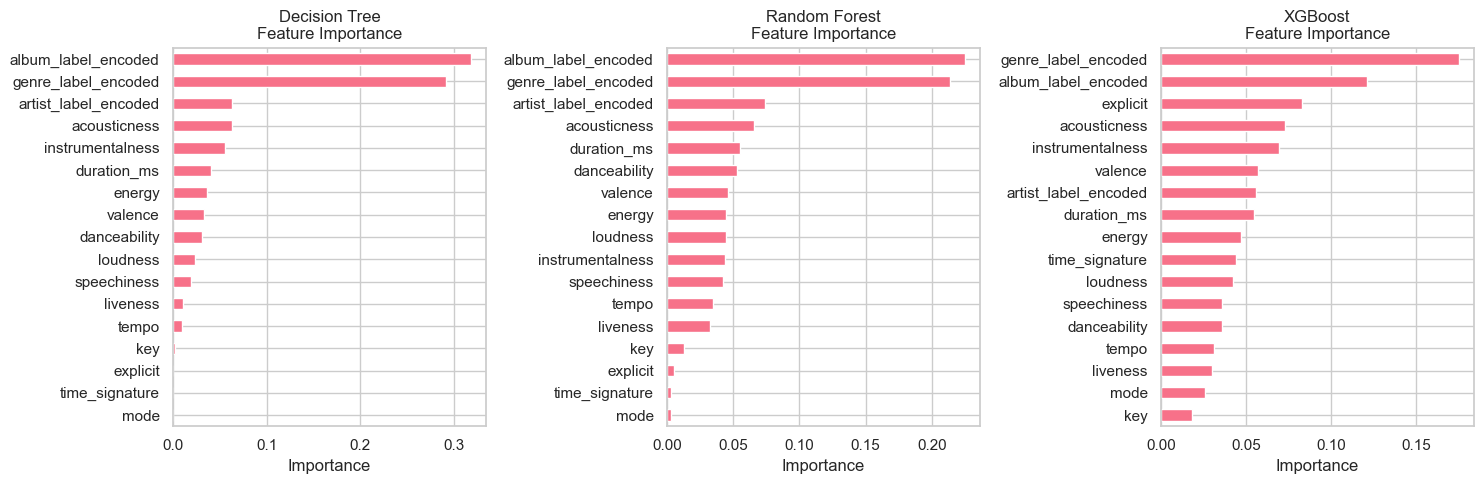


Top 5 Most Important Features by Model:

Decision Tree:
album_label_encoded     0.318609
genre_label_encoded     0.291694
artist_label_encoded    0.063575
acousticness            0.062951
instrumentalness        0.055517
dtype: float64

Random Forest:
album_label_encoded     0.225179
genre_label_encoded     0.213452
artist_label_encoded    0.073989
acousticness            0.065421
duration_ms             0.055407
dtype: float64

XGBoost:
genre_label_encoded    0.175062
album_label_encoded    0.121160
explicit               0.082906
acousticness           0.073007
instrumentalness       0.069318
dtype: float32


In [21]:
# Create feature importance plots for each model
plt.figure(figsize=(15, 5))

# Plot for Decision Tree
plt.subplot(1, 3, 1)
importances_dt = pd.Series(models['Decision Tree'].feature_importances_, index=base_features)
importances_dt.sort_values(ascending=True).plot(kind='barh')
plt.title('Decision Tree\nFeature Importance')
plt.xlabel('Importance')

# Plot for Random Forest
plt.subplot(1, 3, 2)
importances_rf = pd.Series(models['Random Forest'].feature_importances_, index=base_features)
importances_rf.sort_values(ascending=True).plot(kind='barh')
plt.title('Random Forest\nFeature Importance')
plt.xlabel('Importance')

# Plot for XGBoost
plt.subplot(1, 3, 3)
importances_xgb = pd.Series(models['XGBoost'].feature_importances_, index=base_features)
importances_xgb.sort_values(ascending=True).plot(kind='barh')
plt.title('XGBoost\nFeature Importance')
plt.xlabel('Importance')

plt.tight_layout()
plt.show()

# Print feature importance summary
print("\nTop 5 Most Important Features by Model:")
for name in models.keys():
    importances = pd.Series(models[name].feature_importances_, index=base_features)
    print(f"\n{name}:")
    print(importances.sort_values(ascending=False).head())


In [ ]:
# Grid search for Random Forest
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': range(3, 16, 2),
    'n_estimators': range(20, 81, 10)
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best RMSE:", -rf_grid.best_score_)



Best parameters: {'max_depth': 15, 'n_estimators': 80}
Best RMSE: 17.099391604655946


In [23]:
print(rf_grid)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': range(3, 16, 2),
                         'n_estimators': range(20, 81, 10)},
             scoring='neg_root_mean_squared_error')
